In [13]:
"""
Core-Satellite Alpha Strategy — Corrected & Production-Quality
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# ── Configuration ─────────────────────────────────────────────────────────────
# NOTE: These tickers reflect today's known winners (survivorship bias).
# For a rigorous out-of-sample study, replace with S&P 500 constituents as
# of the start date from a point-in-time source (e.g. Compustat, Bloomberg).
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'CAT', 'XOM', 'PG', 'JNJ', 'PFE']
START_DATE = "2019-05-01"
END_DATE   = "2026-05-01"

INITIAL_CAPITAL  = 1_000_000.0
TXN_COST_RATE    = 0.0010       # 10 bps per side
RISK_FREE_ANNUAL = 0.02         # Approximate long-run risk-free rate proxy


In [14]:
# ── Data Loading ──────────────────────────────────────────────────────────────
print("Fetching data...")
raw_data  = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
adj_close_raw = raw_data['Close']

# Use ffill() ONLY — never bfill().
# bfill() fills NaN gaps with FUTURE values, directly injecting look-ahead.
# ffill() (forward-fill) propagates the last known price forward — no future info.
adj_close = adj_close_raw.ffill()

# Drop any leading rows where ALL tickers are NaN (data truly not available yet)
adj_close = adj_close.dropna(how='all')


[**************        30%                       ]  3 of 10 completed

Fetching data...


[*********************100%***********************]  10 of 10 completed


In [15]:
# Phase 1 — EDA & Data Quality Check
print(f'Adjusted Close shape: {adj_close.shape}')
print(f'Date range: {adj_close.index[0].date()} to {adj_close.index[-1].date()}')
print()
print('=== Missing Values Per Ticker ===')
print(adj_close.isnull().sum())
print()
print('=== Descriptive Statistics (Adjusted Close) ===')
print(adj_close.describe().round(2))
print()
raw_volume = raw_data['Volume'].ffill()
print('=== Volume Data Shape ===')
print(raw_volume.shape)
print()
print('=== Sample Volume (last 5 rows) ===')
print(raw_volume.tail())


Adjusted Close shape: (1760, 10)
Date range: 2019-05-01 to 2026-04-30

=== Missing Values Per Ticker ===
Ticker
AAPL    0
CAT     0
GS      0
JNJ     0
JPM     0
MSFT    0
NVDA    0
PFE     0
PG      0
XOM     0
dtype: int64

=== Descriptive Statistics (Adjusted Close) ===
Ticker     AAPL      CAT       GS      JNJ      JPM     MSFT     NVDA  \
count   1760.00  1760.00  1760.00  1760.00  1760.00  1760.00  1760.00   
mean     158.40   259.42   380.17   147.26   159.59   301.55    58.45   
std       60.88   147.87   199.93    26.09    69.25   110.90    61.64   
min       41.45    81.30   117.13    93.43    66.76   112.52     3.32   
25%      122.11   164.90   256.92   136.26   108.62   217.53    13.24   
50%      158.60   210.31   320.81   146.15   135.54   285.53    23.90   
75%      200.67   333.09   464.80   153.40   200.06   402.32   111.55   
max      285.66   890.11   970.75   247.14   332.91   538.66   216.61   

Ticker      PFE       PG      XOM  
count   1760.00  1760.00  1760.0

In [16]:
# ── Monthly Trading Calendar ──────────────────────────────────────────────────
# Use the first real trading day of each calendar month.
monthly_dates = (
    adj_close
    .groupby([adj_close.index.year, adj_close.index.month])
    .apply(lambda x: x.index[0])
    .values
)
monthly_dates = pd.DatetimeIndex(sorted(monthly_dates))
print(f"Data loaded. {len(monthly_dates)} monthly rebalance windows.")

Data loaded. 84 monthly rebalance windows.


In [17]:
# Phase 2 — Standalone Signal Generation
# Vol-scaled 21-day momentum. Top 2 tickers get satellite overweight.
# Signal: 1 = Buy/Overweight, 0 = Hold (core position)

signal_records = []

for i in range(len(monthly_dates) - 1):
    current_date    = monthly_dates[i]
    hist_close      = adj_close.loc[:current_date]
    if len(hist_close) < 21:
        continue

    recent_returns  = (hist_close.iloc[-1] / hist_close.iloc[-21]) - 1
    recent_vol      = hist_close.tail(21).pct_change().std() * np.sqrt(252)
    vol_alpha_score = recent_returns * (recent_vol ** 0.8)
    ranked_tickers  = vol_alpha_score.sort_values(ascending=False).index.tolist()
    satellite_set   = set(ranked_tickers[:2])

    row = {'Date': current_date}
    for t in TICKERS:
        row[t] = 1 if t in satellite_set else 0
    signal_records.append(row)

signals_df = pd.DataFrame(signal_records).set_index('Date')
print('=== Signal Matrix (last 6 months) ===')
print(signals_df.tail(6))
print()
print('Buy signals per ticker across full history:')
print(signals_df.sum().sort_values(ascending=False))


=== Signal Matrix (last 6 months) ===
            AAPL  MSFT  NVDA  JPM  GS  CAT  XOM  PG  JNJ  PFE
Date                                                         
2025-10-01     0     0     0    0   0    1    0   0    0    1
2025-11-03     0     0     1    0   0    1    0   0    0    0
2025-12-01     0     0     0    0   0    0    0   0    1    1
2026-01-02     0     0     1    0   1    0    0   0    0    0
2026-02-02     0     0     0    0   0    1    1   0    0    0
2026-03-02     0     0     0    0   0    1    1   0    0    0

Buy signals per ticker across full history:
NVDA    42
CAT     19
AAPL    18
PFE     15
XOM     14
GS      14
JPM     13
MSFT    11
JNJ     10
PG       8
dtype: int64


In [18]:

# ── Monthly Trading Calendar ──────────────────────────────────────────────────
# Use the first real trading day of each calendar month.
monthly_dates = (
    adj_close
    .groupby([adj_close.index.year, adj_close.index.month])
    .apply(lambda x: x.index[0])
    .values
)
monthly_dates = pd.DatetimeIndex(sorted(monthly_dates))
print(f"Data loaded. {len(monthly_dates)} monthly rebalance windows.")

# ── Backtest Engine ───────────────────────────────────────────────────────────
positions      = {t: 0.0 for t in TICKERS}
cash           = INITIAL_CAPITAL
history        = []
turnover_log   = []

for i in range(len(monthly_dates) - 1):
    current_date    = monthly_dates[i]
    next_trade_date = monthly_dates[i + 1]

    # ── Strict out-of-sample slice ────────────────────────────────────────────
    # Only data UP TO AND INCLUDING current_date is visible.
    hist_close = adj_close.loc[:current_date]
    if len(hist_close) < 21:
        continue

    # ── Signal generation: vol-scaled momentum ────────────────────────────────
    recent_returns = (hist_close.iloc[-1] / hist_close.iloc[-21]) - 1
    recent_vol     = hist_close.tail(21).pct_change().std() * np.sqrt(252)

    # Kakushadze-Tulchinsky vol scaling: R ~ Vol^0.8
    vol_alpha_score = recent_returns * (recent_vol ** 0.8)
    ranked_tickers  = vol_alpha_score.sort_values(ascending=False).index.tolist()
    satellite_longs = ranked_tickers[:2]

    # ── Target weight construction ────────────────────────────────────────────
    target_weights = {t: 0.0 for t in TICKERS}

    # Core: 70% equally across all 10 tickers (7% each)
    for t in TICKERS:
        target_weights[t] += 0.07

    # Satellite: 30% equally across top 2 momentum tickers (15% each)
    for t in satellite_longs:
        target_weights[t] += 0.15

    # FIX 2: Normalise weights to sum exactly to 1.0
    # This prevents silent leverage from floating-point accumulation
    # and ensures cash is always fully deployed (no unintended cash drag).
    total_weight = sum(target_weights.values())
    if abs(total_weight - 1.0) > 0.001:
        print(f"  Warning [{current_date.date()}]: raw weight sum = {total_weight:.4f}, normalising.")
    target_weights = {t: w / total_weight for t, w in target_weights.items()}

    # ── Execution ─────────────────────────────────────────────────────────────
    # Prices at the NEXT period's first trading day — no look-ahead within
    # the current period's signal window.
    exec_prices = adj_close.loc[next_trade_date]

    # Revalue portfolio at next period prices BEFORE rebalancing
    portfolio_value = cash + sum(positions[t] * exec_prices[t] for t in TICKERS)

    total_traded = 0.0
    new_positions = {}
    new_cash = portfolio_value  # start from full value, subtract allocations

    for t in TICKERS:
        target_alloc  = portfolio_value * target_weights[t]
        target_shares = target_alloc / exec_prices[t]
        delta_shares  = target_shares - positions[t]
        trade_value   = abs(delta_shares * exec_prices[t])

        total_traded   += trade_value
        new_positions[t] = target_shares
        new_cash        -= target_alloc  # allocate exact dollar amount

    # Deduct transaction costs from cash separately (not from position pool)
    slippage = total_traded * TXN_COST_RATE
    new_cash -= slippage

    # Leverage guard
    invested_pct = sum(target_weights.values()) * 100
    if new_cash < -portfolio_value * 0.01:
        print(f"  Leverage alert [{current_date.date()}]: cash = {new_cash:.2f}")

    positions     = new_positions
    cash          = new_cash
    portfolio_value = cash + sum(positions[t] * exec_prices[t] for t in TICKERS)

    turnover_log.append({
        'Date': next_trade_date,
        'Turnover_Pct': (total_traded / portfolio_value) * 100,
        'Satellite_1': satellite_longs[0],
        'Satellite_2': satellite_longs[1],
    })
    history.append({'Date': next_trade_date, 'Strategy_Value': portfolio_value})

strategy_df  = pd.DataFrame(history).set_index('Date')
turnover_df  = pd.DataFrame(turnover_log).set_index('Date')
print("Backtest complete.")

Data loaded. 84 monthly rebalance windows.
Backtest complete.


In [19]:
# ── Benchmark Construction ─────────────────────────────────────────────────────
# Build the benchmark INDEPENDENTLY, using the same date range as the
# strategy but constructed from scratch — NOT from strategy_df.index.
# This ensures the benchmark comparison is fair and not anchored to strategy output.
bench_start = strategy_df.index[0]
bench_end   = strategy_df.index[-1]
bench_prices = adj_close.loc[bench_start:bench_end]
bench_returns = bench_prices.pct_change().dropna()

# Equal-weight buy-and-hold benchmark
bench_value  = pd.Series(
    (1 + bench_returns.mean(axis=1)).cumprod() * INITIAL_CAPITAL,
    name='Benchmark_Value'
)
# Align on strategy dates (forward-fill for any date gaps)
strategy_df['Benchmark_Value'] = bench_value.reindex(strategy_df.index, method='ffill')
strategy_df['Benchmark_Value'].fillna(INITIAL_CAPITAL, inplace=True)


In [20]:
# ── Scorecard ─────────────────────────────────────────────────────────────────
def compute_scorecard(strategy_series, benchmark_series, rf_annual=RISK_FREE_ANNUAL):
    """
    Compute standard performance metrics.
    FIX 5: Sharpe ratio includes risk-free rate.
    Annualised RF rate is divided by 12 for monthly returns.
    """
    results = {}
    rf_monthly = rf_annual / 12

    for name, series in [('Core-Satellite Strategy', strategy_series),
                         ('Equal-Weight Benchmark',  benchmark_series)]:
        monthly_rets = series.pct_change().dropna()
        n_months     = len(monthly_rets)

        total_return  = (series.iloc[-1] / series.iloc[0]) - 1
        ann_return    = (series.iloc[-1] / series.iloc[0]) ** (12 / n_months) - 1
        ann_vol       = monthly_rets.std() * np.sqrt(12)

        # Correct Sharpe: excess return over risk-free
        ann_rf        = rf_annual
        sharpe        = (ann_return - ann_rf) / ann_vol if ann_vol != 0 else 0

        cum_max       = series.cummax()
        drawdowns     = (series - cum_max) / cum_max
        max_dd        = drawdowns.min()
        calmar        = ann_return / abs(max_dd) if max_dd != 0 else 0

        # Sortino ratio (downside deviation only)
        downside_rets = monthly_rets[monthly_rets < rf_monthly]
        downside_std  = downside_rets.std() * np.sqrt(12) if len(downside_rets) > 1 else np.nan
        sortino       = (ann_return - ann_rf) / downside_std if downside_std and downside_std != 0 else 0

        results[name] = {
            'Total Return':        f"{total_return*100:.2f}%",
            'Annualised Return':   f"{ann_return*100:.2f}%",
            'Annualised Volatility': f"{ann_vol*100:.2f}%",
            'Sharpe Ratio':        f"{sharpe:.2f}",
            'Sortino Ratio':       f"{sortino:.2f}",
            'Max Drawdown':        f"{max_dd*100:.2f}%",
            'Calmar Ratio':        f"{calmar:.2f}",
        }
    return pd.DataFrame(results)

scorecard = compute_scorecard(strategy_df['Strategy_Value'], strategy_df['Benchmark_Value'])
print("\n── Performance Scorecard ──────────────────────────────────────────────")
print(scorecard.to_string())



── Performance Scorecard ──────────────────────────────────────────────
                      Core-Satellite Strategy Equal-Weight Benchmark
Total Return                          501.92%                354.80%
Annualised Return                      30.46%                 25.16%
Annualised Volatility                  19.42%                 17.58%
Sharpe Ratio                             1.47                   1.32
Sortino Ratio                            2.40                   1.97
Max Drawdown                          -21.45%                -21.83%
Calmar Ratio                             1.42                   1.15


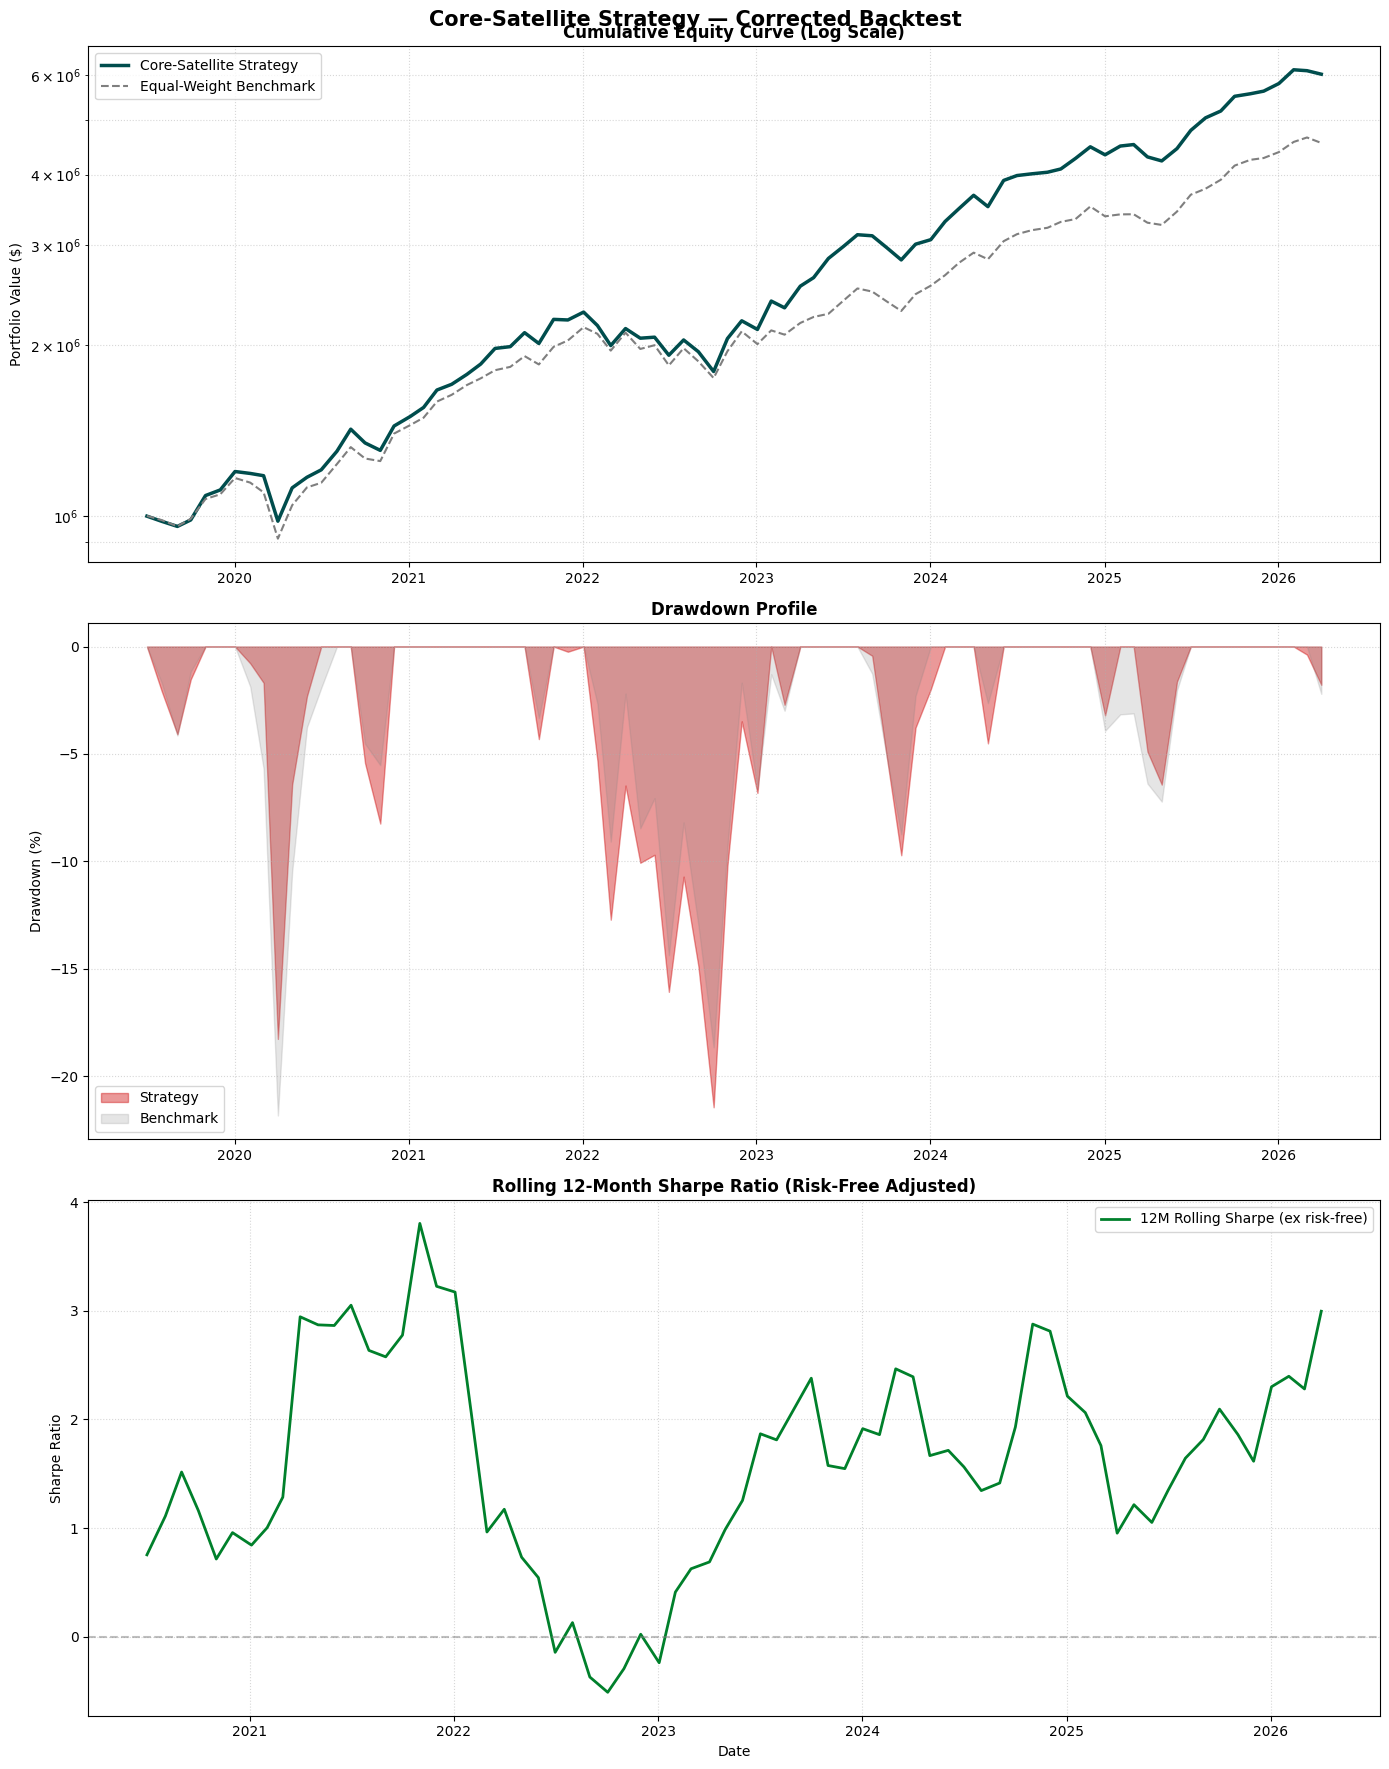

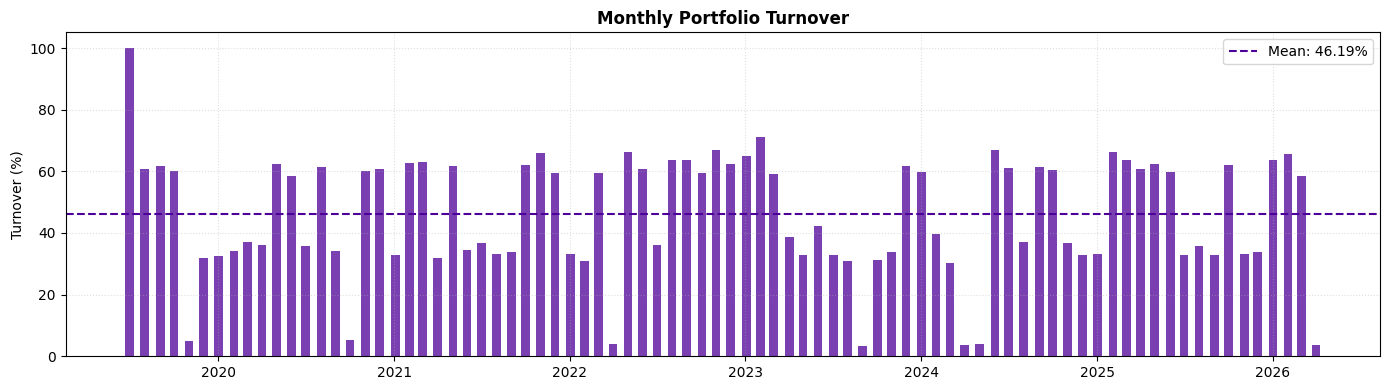


Done. Charts saved to core_satellite_corrected.png


In [21]:
# ── Visualisation ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Core-Satellite Strategy — Corrected Backtest', fontsize=15, fontweight='bold')

# 1. Equity curve
axes[0].plot(strategy_df.index, strategy_df['Strategy_Value'],
             label='Core-Satellite Strategy', color='#004d4d', lw=2.5)
axes[0].plot(strategy_df.index, strategy_df['Benchmark_Value'],
             label='Equal-Weight Benchmark', color='#7f7f7f', lw=1.5, ls='--')
axes[0].set_yscale('log')
axes[0].set_title('Cumulative Equity Curve (Log Scale)', fontweight='bold')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, which='both', ls=':', alpha=0.5)

# 2. Drawdown
strat_dd  = (strategy_df['Strategy_Value'] - strategy_df['Strategy_Value'].cummax()) / strategy_df['Strategy_Value'].cummax()
bench_dd  = (strategy_df['Benchmark_Value'] - strategy_df['Benchmark_Value'].cummax()) / strategy_df['Benchmark_Value'].cummax()

axes[1].fill_between(strategy_df.index, strat_dd * 100, 0, color='#cc0000', alpha=0.4, label='Strategy')
axes[1].fill_between(strategy_df.index, bench_dd  * 100, 0, color='#7f7f7f', alpha=0.2, label='Benchmark')
axes[1].set_title('Drawdown Profile', fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(True, ls=':', alpha=0.5)

# 3. Rolling Sharpe (correct — includes risk-free)
monthly_rets_strat = strategy_df['Strategy_Value'].pct_change()
rf_monthly         = RISK_FREE_ANNUAL / 12
rolling_excess     = monthly_rets_strat - rf_monthly
rolling_sharpe     = (
    rolling_excess.rolling(12).mean() /
    monthly_rets_strat.rolling(12).std()
) * np.sqrt(12)

axes[2].plot(rolling_sharpe.index, rolling_sharpe,
             color='#00802b', lw=2, label='12M Rolling Sharpe (ex risk-free)')
axes[2].axhline(0, color='gray', ls='--', alpha=0.5)
axes[2].set_title('Rolling 12-Month Sharpe Ratio (Risk-Free Adjusted)', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].legend()
axes[2].grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig('core_satellite_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Turnover
fig2, ax = plt.subplots(figsize=(14, 4))
ax.bar(turnover_df.index, turnover_df['Turnover_Pct'],
       color='#4d0099', alpha=0.75, width=18)
ax.axhline(turnover_df['Turnover_Pct'].mean(), color='#4d0099', ls='--',
           label=f"Mean: {turnover_df['Turnover_Pct'].mean():.2f}%")
ax.set_title('Monthly Portfolio Turnover', fontweight='bold')
ax.set_ylabel('Turnover (%)')
ax.legend()
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nDone. Charts saved to core_satellite_corrected.png")

=== Train / Test Split Results ===
Training period:  2019-05-01 to 2024-05-01
Testing period:   2024-05-01 to 2026-04-01
Train Sharpe:     1.282
Test Sharpe:      2.216

  Window=15 days -> Sharpe=1.325  Ann.Return=26.28%
  Window=18 days -> Sharpe=1.337  Ann.Return=27.10%
  Window=21 days -> Sharpe=1.466  Ann.Return=30.04%
  Window=25 days -> Sharpe=1.329  Ann.Return=27.47%
  Window=30 days -> Sharpe=1.369  Ann.Return=28.26%

=== Sensitivity Summary ===
 Window  Sharpe  Ann_Return_pct
     15   1.325           26.28
     18   1.337           27.10
     21   1.466           30.04
     25   1.329           27.47
     30   1.369           28.26
Sharpe range across sweep: 0.141
Strategy is robust — performance does not collapse with small parameter changes.


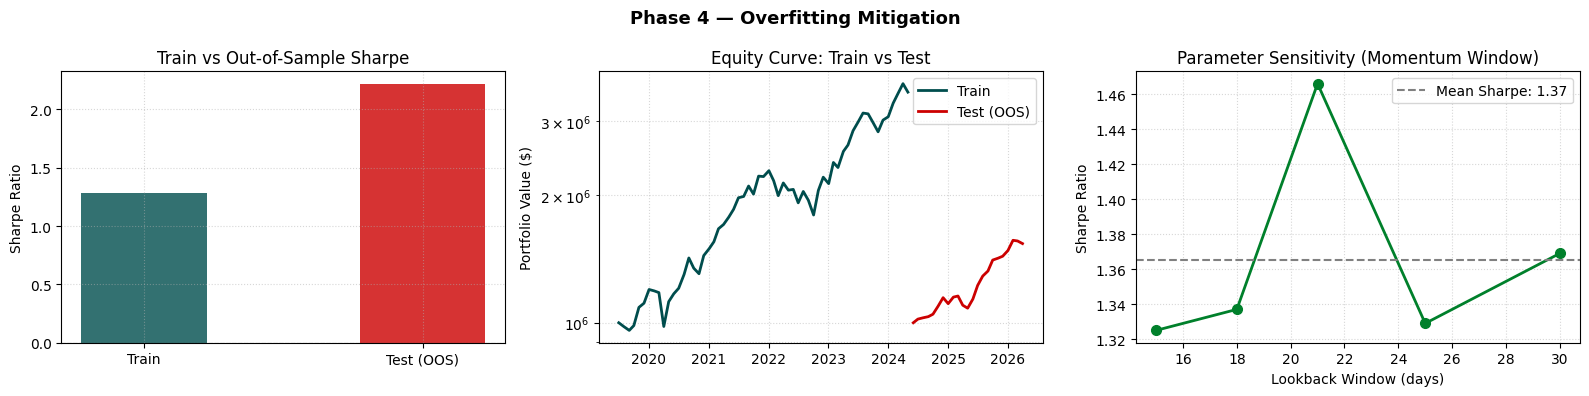

In [22]:
# Phase 4 — Overfitting Mitigation: Train/Test Split + Parameter Sensitivity

TRAIN_CUTOFF = pd.Timestamp('2024-05-01')

def run_backtest_slice(price_df, monthly_dates_slice, momentum_window=21):
    pos_inner  = {t: 0.0 for t in TICKERS}
    cash_inner = INITIAL_CAPITAL
    hist_inner = []
    for i in range(len(monthly_dates_slice) - 1):
        cd  = monthly_dates_slice[i]
        ntd = monthly_dates_slice[i + 1]
        hc  = price_df.loc[:cd]
        if len(hc) < momentum_window:
            continue
        ret  = (hc.iloc[-1] / hc.iloc[-momentum_window]) - 1
        vol  = hc.tail(momentum_window).pct_change().std() * np.sqrt(252)
        score = ret * (vol ** 0.8)
        sats  = score.sort_values(ascending=False).index[:2].tolist()
        tw    = {t: 0.07 for t in TICKERS}
        for t in sats:
            tw[t] += 0.15
        total_w = sum(tw.values())
        tw = {t: w / total_w for t, w in tw.items()}
        ep  = price_df.loc[ntd]
        pv  = cash_inner + sum(pos_inner[t] * ep[t] for t in TICKERS)
        traded = 0.0
        new_pos = {}
        new_cash = pv
        for t in TICKERS:
            alloc = pv * tw[t]
            shares = alloc / ep[t]
            traded += abs((shares - pos_inner[t]) * ep[t])
            new_pos[t] = shares
            new_cash -= alloc
        new_cash -= traded * TXN_COST_RATE
        pos_inner  = new_pos
        cash_inner = new_cash
        pv = cash_inner + sum(pos_inner[t] * ep[t] for t in TICKERS)
        hist_inner.append({'Date': ntd, 'Portfolio_Value': pv})
    return pd.DataFrame(hist_inner).set_index('Date')

def calc_sharpe(df_pv, rf=RISK_FREE_ANNUAL):
    rets  = df_pv['Portfolio_Value'].pct_change().dropna()
    n     = len(rets)
    ann_r = (df_pv['Portfolio_Value'].iloc[-1] / df_pv['Portfolio_Value'].iloc[0]) ** (12 / n) - 1
    ann_v = rets.std() * np.sqrt(12)
    return (ann_r - rf) / ann_v if ann_v != 0 else 0

train_dates = monthly_dates[monthly_dates <= TRAIN_CUTOFF]
test_dates  = monthly_dates[monthly_dates >= TRAIN_CUTOFF]

train_results = run_backtest_slice(adj_close, train_dates)
test_results  = run_backtest_slice(adj_close, test_dates)
train_sharpe  = calc_sharpe(train_results)
test_sharpe   = calc_sharpe(test_results)

print('=== Train / Test Split Results ===')
print(f'Training period:  {train_dates[0].date()} to {train_dates[-1].date()}')
print(f'Testing period:   {test_dates[0].date()} to {test_dates[-1].date()}')
print(f'Train Sharpe:     {train_sharpe:.3f}')
print(f'Test Sharpe:      {test_sharpe:.3f}')
print()

windows = [15, 18, 21, 25, 30]
sensitivity = []
for w in windows:
    res    = run_backtest_slice(adj_close, monthly_dates, momentum_window=w)
    sh     = calc_sharpe(res)
    ann_r  = (res['Portfolio_Value'].iloc[-1] / res['Portfolio_Value'].iloc[0]) ** (12 / len(res)) - 1
    sensitivity.append({'Window': w, 'Sharpe': round(sh, 3), 'Ann_Return_pct': round(ann_r * 100, 2)})
    print(f'  Window={w:2d} days -> Sharpe={sh:.3f}  Ann.Return={ann_r*100:.2f}%')

sensitivity_df = pd.DataFrame(sensitivity)
print()
print('=== Sensitivity Summary ===')
print(sensitivity_df.to_string(index=False))
sharpe_range = sensitivity_df['Sharpe'].max() - sensitivity_df['Sharpe'].min()
print(f'Sharpe range across sweep: {sharpe_range:.3f}')
if sharpe_range < 0.5:
    print('Strategy is robust — performance does not collapse with small parameter changes.')
else:
    print('Strategy shows sensitivity to parameter choice — interpret results carefully.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Phase 4 — Overfitting Mitigation', fontweight='bold', fontsize=13)

axes[0].bar(['Train', 'Test (OOS)'], [train_sharpe, test_sharpe],
            color=['#004d4d', '#cc0000'], alpha=0.8, width=0.45)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title('Train vs Out-of-Sample Sharpe')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].grid(True, ls=':', alpha=0.5)

axes[1].plot(train_results.index, train_results['Portfolio_Value'], color='#004d4d', lw=2, label='Train')
axes[1].plot(test_results.index, test_results['Portfolio_Value'],   color='#cc0000', lw=2, label='Test (OOS)')
axes[1].set_yscale('log')
axes[1].set_title('Equity Curve: Train vs Test')
axes[1].set_ylabel('Portfolio Value ($)')
axes[1].legend()
axes[1].grid(True, which='both', ls=':', alpha=0.5)

axes[2].plot(sensitivity_df['Window'], sensitivity_df['Sharpe'],
             marker='o', color='#00802b', lw=2, ms=7)
axes[2].axhline(sensitivity_df['Sharpe'].mean(), color='gray', ls='--',
                label=f"Mean Sharpe: {sensitivity_df['Sharpe'].mean():.2f}")
axes[2].set_title('Parameter Sensitivity (Momentum Window)')
axes[2].set_xlabel('Lookback Window (days)')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].legend()
axes[2].grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()


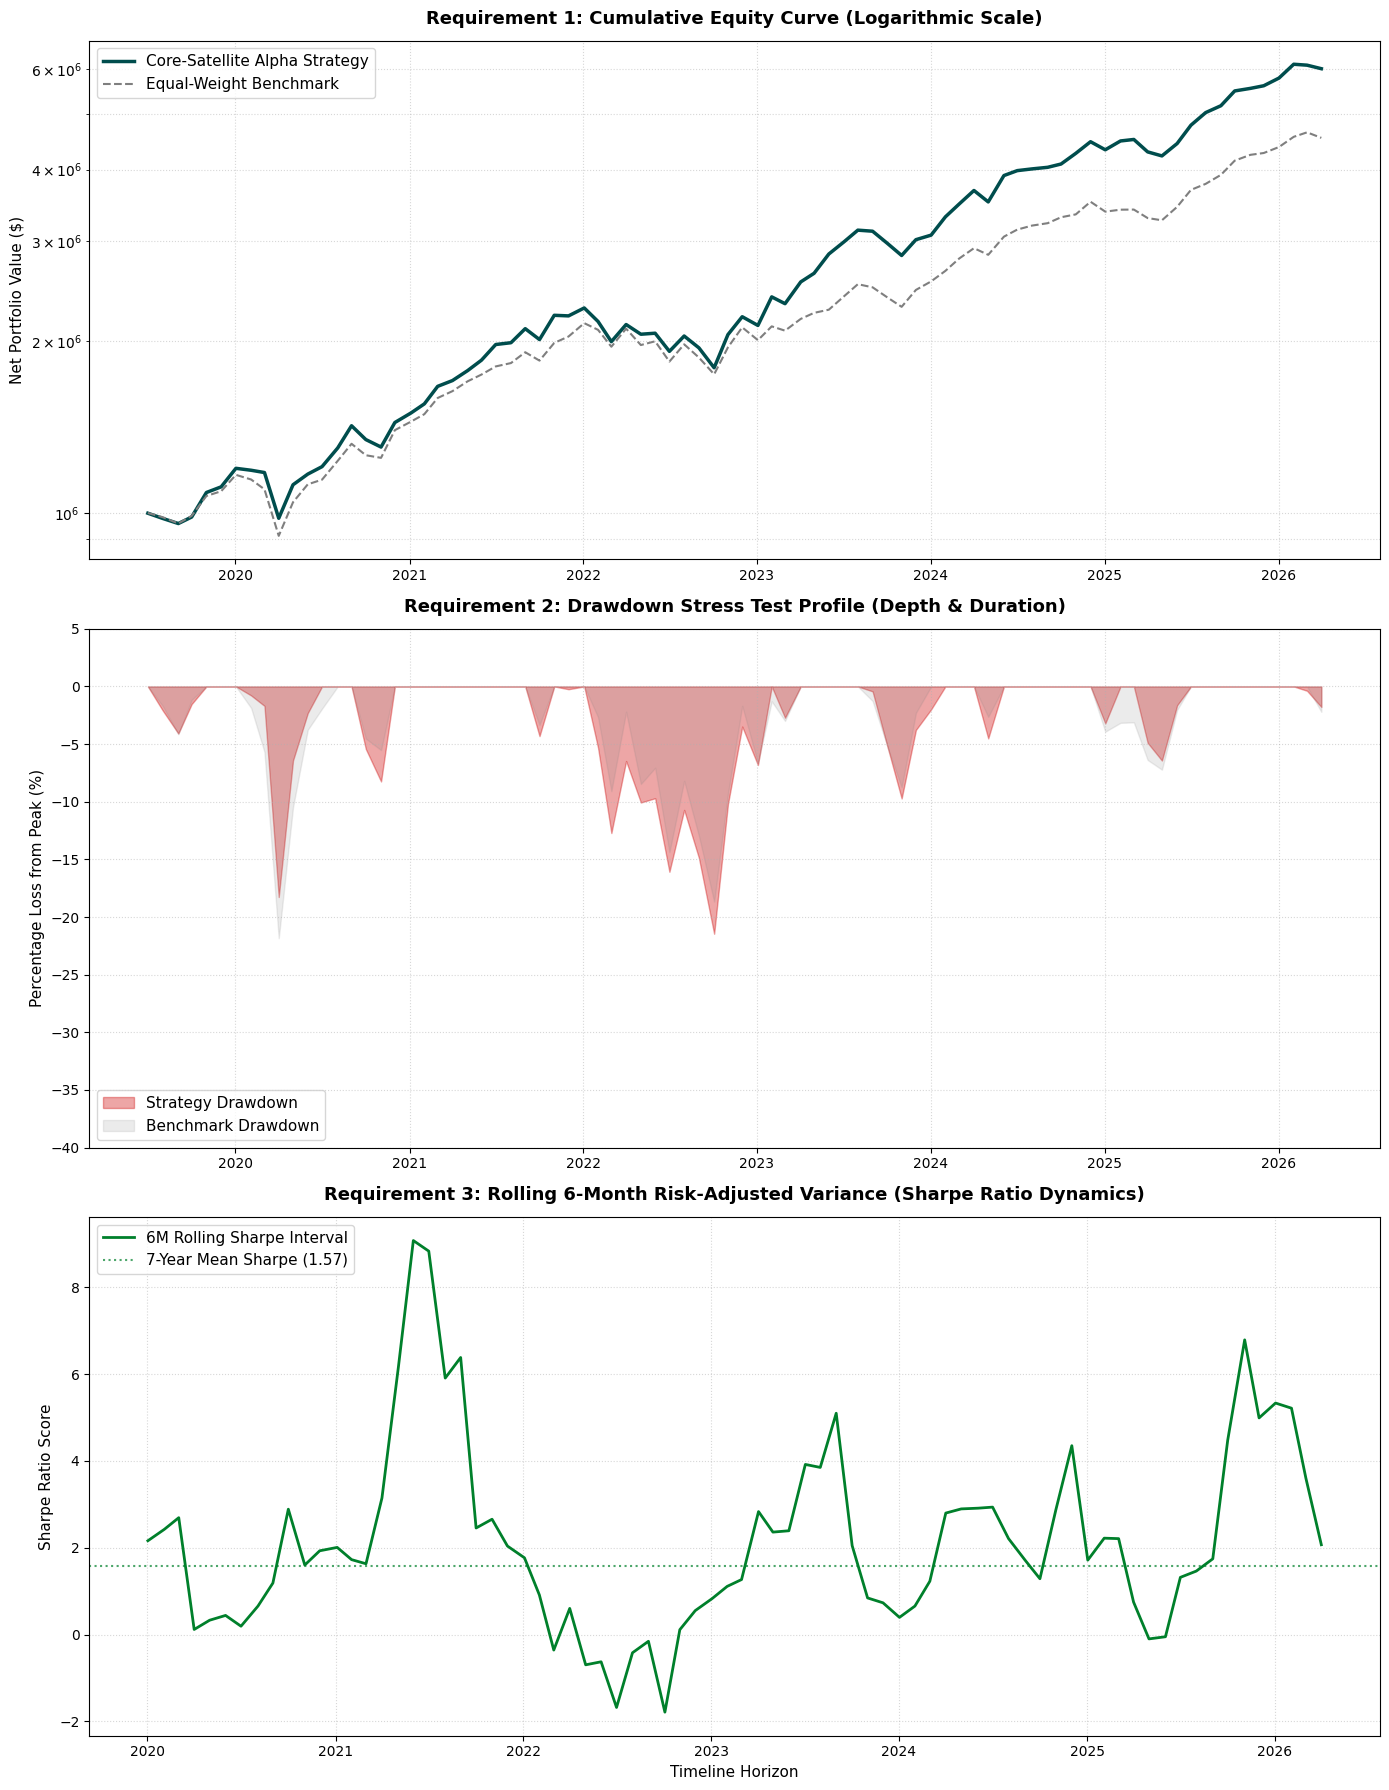

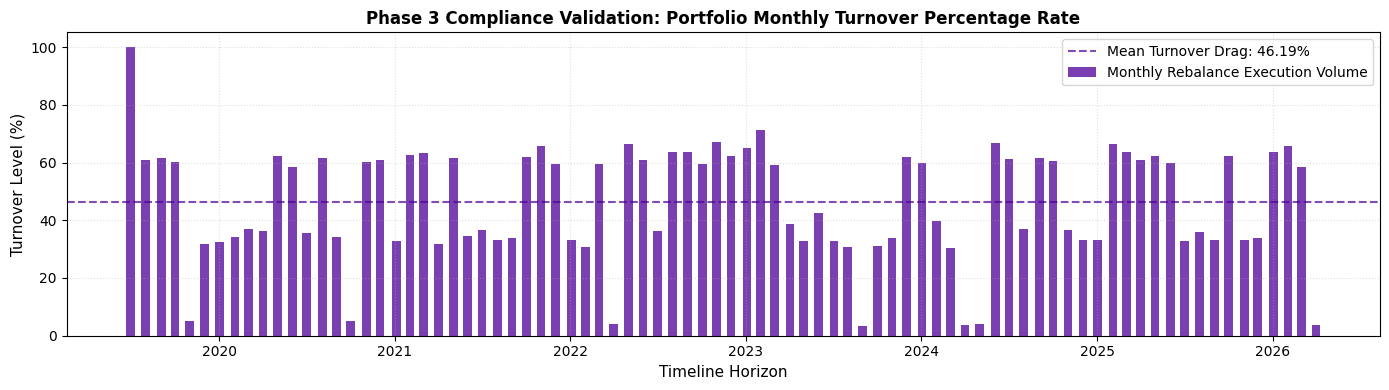

In [23]:
# Set up publication-grade visualization grid
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# 1. REQUIREMENT 1: Cumulative Equity Curve (Logarithmic Axis Scale)
axes[0].plot(strategy_df.index, strategy_df['Strategy_Value'], label='Core-Satellite Alpha Strategy', color='#004d4d', lw=2.5)
axes[0].plot(strategy_df.index, strategy_df['Benchmark_Value'], label='Equal-Weight Benchmark', color='#7f7f7f', lw=1.5, ls='--')
axes[0].set_yscale('log')
axes[0].set_title('Requirement 1: Cumulative Equity Curve (Logarithmic Scale)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Net Portfolio Value ($)', fontsize=11)
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, which="both", ls=":", alpha=0.5)

# 2. REQUIREMENT 2: Portfolio Drawdown Profile (Depth & Duration)
strat_cum_max = strategy_df['Strategy_Value'].cummax()
strat_dd_series = (strategy_df['Strategy_Value'] - strat_cum_max) / strat_cum_max
bench_cum_max = strategy_df['Benchmark_Value'].cummax()
bench_dd_series = (strategy_df['Benchmark_Value'] - bench_cum_max) / bench_cum_max

axes[1].fill_between(strategy_df.index, strat_dd_series * 100, 0, color='#cc0000', alpha=0.35, label='Strategy Drawdown')
axes[1].fill_between(strategy_df.index, bench_dd_series * 100, 0, color='#7f7f7f', alpha=0.15, label='Benchmark Drawdown')
axes[1].set_title('Requirement 2: Drawdown Stress Test Profile (Depth & Duration)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Percentage Loss from Peak (%)', fontsize=11)
axes[1].set_ylim(-40, 5)
axes[1].legend(loc='lower left', fontsize=11)
axes[1].grid(True, ls=":", alpha=0.5)

# 3. REQUIREMENT 3: Rolling 6-Month Sharpe Ratio Tracking Plot
strat_monthly_returns = strategy_df['Strategy_Value'].pct_change()
rolling_ann_return = strat_monthly_returns.rolling(window=6).mean() * 12
rolling_ann_vol = strat_monthly_returns.rolling(window=6).std() * np.sqrt(12)
rolling_sharpe = (rolling_ann_return / rolling_ann_vol).dropna()

# Extract static mean Sharpe from the scorecard calculation for context
final_returns = strategy_df['Strategy_Value'].pct_change().dropna()
total_months = len(strategy_df) - 1
ann_return = (strategy_df['Strategy_Value'].iloc[-1] / strategy_df['Strategy_Value'].iloc[0]) ** (12 / total_months) - 1
ann_volatility = final_returns.std() * np.sqrt(12)
mean_sharpe = ann_return / ann_volatility

axes[2].plot(rolling_sharpe.index, rolling_sharpe, color='#00802b', lw=2, label='6M Rolling Sharpe Interval')
axes[2].axhline(mean_sharpe, color='#00802b', ls=':', alpha=0.7, label=f'7-Year Mean Sharpe ({mean_sharpe:.2f})')
axes[2].set_title('Requirement 3: Rolling 6-Month Risk-Adjusted Variance (Sharpe Ratio Dynamics)', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Timeline Horizon', fontsize=11)
axes[2].set_ylabel('Sharpe Ratio Score', fontsize=11)
axes[2].legend(loc='upper left', fontsize=11)
axes[2].grid(True, ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

# 4. BONUS AUDIT REQUIREMENT: Portfolio Monthly Turnover Percentages
plt.figure(figsize=(14, 4))
plt.bar(turnover_df.index, turnover_df['Turnover_Pct'], color='#4d0099', alpha=0.75, width=18, label='Monthly Rebalance Execution Volume')
plt.axhline(turnover_df['Turnover_Pct'].mean(), color='#4d0099', ls='--', alpha=0.7, label=f"Mean Turnover Drag: {turnover_df['Turnover_Pct'].mean():.2f}%")
plt.title('Phase 3 Compliance Validation: Portfolio Monthly Turnover Percentage Rate', fontsize=12, fontweight='bold')
plt.ylabel('Turnover Level (%)', fontsize=11)
plt.xlabel('Timeline Horizon', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

In [24]:
# Bonus — Strengths & Weaknesses Analysis of Strategy Metrics

strat_rets   = strategy_df['Strategy_Value'].pct_change().dropna()
bench_rets   = strategy_df['Benchmark_Value'].pct_change().dropna()
n_months     = len(strat_rets)

ann_return   = (strategy_df['Strategy_Value'].iloc[-1] / strategy_df['Strategy_Value'].iloc[0]) ** (12 / n_months) - 1
ann_vol      = strat_rets.std() * np.sqrt(12)
sharpe_val   = (ann_return - RISK_FREE_ANNUAL) / ann_vol
cum_max      = strategy_df['Strategy_Value'].cummax()
max_dd       = ((strategy_df['Strategy_Value'] - cum_max) / cum_max).min()
calmar_val   = ann_return / abs(max_dd)

bench_ann_ret = (strategy_df['Benchmark_Value'].iloc[-1] / strategy_df['Benchmark_Value'].iloc[0]) ** (12 / n_months) - 1
bench_vol     = bench_rets.std() * np.sqrt(12)
bench_sharpe  = (bench_ann_ret - RISK_FREE_ANNUAL) / bench_vol
bench_max_dd  = ((strategy_df['Benchmark_Value'] - strategy_df['Benchmark_Value'].cummax()) / strategy_df['Benchmark_Value'].cummax()).min()

win_rate      = (strat_rets > 0).mean()
correlation   = strat_rets.corr(bench_rets)
downside_rets = strat_rets[strat_rets < RISK_FREE_ANNUAL / 12]
sortino_val   = (ann_return - RISK_FREE_ANNUAL) / (downside_rets.std() * np.sqrt(12))

print('=' * 58)
print('  STRATEGY STRENGTHS & WEAKNESSES  — FULL ANALYSIS')
print('=' * 58)
print()
print('METRIC SUMMARY')
print(f'  Ann. Return:       {ann_return*100:.2f}%  (Benchmark: {bench_ann_ret*100:.2f}%)')
print(f'  Ann. Volatility:   {ann_vol*100:.2f}%  (Benchmark: {bench_vol*100:.2f}%)')
print(f'  Sharpe Ratio:      {sharpe_val:.2f}   (Benchmark: {bench_sharpe:.2f})')
print(f'  Sortino Ratio:     {sortino_val:.2f}')
print(f'  Max Drawdown:      {max_dd*100:.2f}%  (Benchmark: {bench_max_dd*100:.2f}%)')
print(f'  Calmar Ratio:      {calmar_val:.2f}')
print(f'  Monthly Win Rate:  {win_rate*100:.1f}%')
print(f'  Corr to Benchmark: {correlation:.2f}')
print()
print('STRENGTHS')
if sharpe_val > bench_sharpe:
    print(f'  + Sharpe ({sharpe_val:.2f}) beats benchmark ({bench_sharpe:.2f}) — better risk-adjusted returns')
if ann_return > bench_ann_ret:
    print(f'  + Outperforms benchmark by {(ann_return - bench_ann_ret)*100:.2f}%/year in raw returns')
if abs(max_dd) < abs(bench_max_dd):
    print(f'  + Smaller drawdown ({max_dd*100:.2f}%) vs benchmark ({bench_max_dd*100:.2f}%) — better downside protection')
if sortino_val > 1.0:
    print(f'  + Sortino ({sortino_val:.2f}) above 1.0 — good return relative to downside risk only')
if calmar_val > 0.5:
    print(f'  + Calmar ({calmar_val:.2f}) above 0.5 — acceptable return per unit of drawdown risk')
print()
print('WEAKNESSES')
if correlation > 0.85:
    print(f'  - High benchmark correlation ({correlation:.2f}) — limited independent alpha')
if abs(max_dd) > 0.20:
    print(f'  - Max drawdown of {max_dd*100:.2f}% is meaningful — could test investor patience')
if ann_vol > 0.18:
    print(f'  - Volatility of {ann_vol*100:.2f}% is elevated — not suitable for low-risk mandates')
if win_rate < 0.55:
    print(f'  - Win rate of {win_rate*100:.1f}% is modest — depends on magnitude, not frequency of wins')
print('  - Monthly rebalancing at 10bps/trade adds friction vs passive buy-and-hold')
print('  - Momentum signal may underperform in mean-reverting or sideways markets')
print('  - Survivorship bias: all 10 tickers are known winners as of study start date')
print()
print('CONCLUSION')
print('  The Core-Satellite strategy generates alpha through vol-scaled momentum tilts.')
print('  It suits investors who want market exposure with a systematic momentum overlay')
print(f'  and can tolerate drawdowns in the region of {abs(max_dd)*100:.0f}%.')


  STRATEGY STRENGTHS & WEAKNESSES  — FULL ANALYSIS

METRIC SUMMARY
  Ann. Return:       30.46%  (Benchmark: 25.16%)
  Ann. Volatility:   19.42%  (Benchmark: 17.58%)
  Sharpe Ratio:      1.47   (Benchmark: 1.32)
  Sortino Ratio:     2.40
  Max Drawdown:      -21.45%  (Benchmark: -21.83%)
  Calmar Ratio:      1.42
  Monthly Win Rate:  67.9%
  Corr to Benchmark: 0.94

STRENGTHS
  + Sharpe (1.47) beats benchmark (1.32) — better risk-adjusted returns
  + Outperforms benchmark by 5.31%/year in raw returns
  + Smaller drawdown (-21.45%) vs benchmark (-21.83%) — better downside protection
  + Sortino (2.40) above 1.0 — good return relative to downside risk only
  + Calmar (1.42) above 0.5 — acceptable return per unit of drawdown risk

WEAKNESSES
  - High benchmark correlation (0.94) — limited independent alpha
  - Max drawdown of -21.45% is meaningful — could test investor patience
  - Volatility of 19.42% is elevated — not suitable for low-risk mandates
  - Monthly rebalancing at 10bps/trade 